Zeta       | Resonance Ratio (r)  | Peak Amplitude 
--------------------------------------------------
0.05       | 0.9975               | 10.0125        
0.1        | 0.9899               | 5.0252         
0.2        | 0.9592               | 2.5516         
0.5        | 0.7071               | 1.1547         
0.707      | 0.0174               | 1.0000         
1.0        | N/A                  | 1.0000         


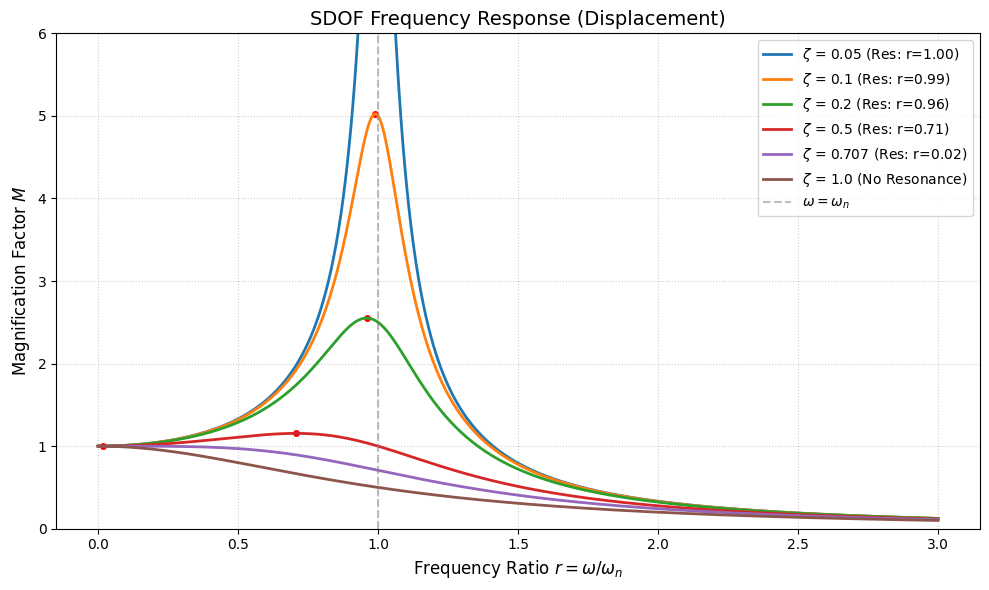

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def plot_sdof_response(zeta_list, r_max=3):
    """
    绘制不同阻尼比下的 SDOF 频率响应（幅值比）
    zeta_list: 阻尼比列表, e.g., [0.1, 0.2, 0.5]
    r_max: 频率比 (w/wn) 的显示上限
    """
    r = np.linspace(0, r_max, 1000)
    plt.figure(figsize=(10, 6))
    
    print(f"{'Zeta':<10} | {'Resonance Ratio (r)':<20} | {'Peak Amplitude':<15}")
    print("-" * 50)

    for zeta in zeta_list:
        # 计算幅值比 (Magnification Factor) M = 1 / sqrt((1-r^2)^2 + (2*zeta*r)^2)
        # 这里基于你之前讨论的 harmonic excitation 公式
        M = 1 / np.sqrt((1 - r**2)**2 + (2 * zeta * r)**2)
        
        # 寻找共振点：对于位移响应，r_res = sqrt(1 - 2*zeta^2)
        if zeta < 1/np.sqrt(2):
            r_res = np.sqrt(1 - 2 * zeta**2)
            M_max = 1 / (2 * zeta * np.sqrt(1 - zeta**2))
            label = f'$\\zeta$ = {zeta} (Res: r={r_res:.2f})'
            # 在图上标记共振点
            plt.plot(r_res, M_max, 'ro', markersize=4)
            print(f"{zeta:<10} | {r_res:<20.4f} | {M_max:<15.4f}")
        else:
            r_res = 0
            M_max = 1
            label = f'$\\zeta$ = {zeta} (No Resonance)'
            print(f"{zeta:<10} | {'N/A':<20} | {M_max:<15.4f}")

        plt.plot(r, M, label=label, linewidth=2)

    plt.title('SDOF Frequency Response (Displacement)', fontsize=14)
    plt.xlabel('Frequency Ratio $r = \omega/\omega_n$', fontsize=12)
    plt.ylabel('Magnification Factor $M$', fontsize=12)
    plt.axvline(1.0, color='gray', linestyle='--', alpha=0.5, label='$\omega = \omega_n$')
    plt.grid(True, which='both', linestyle=':', alpha=0.6)
    plt.legend()
    plt.ylim(0, 6)
    plt.tight_layout()
    plt.show()

# 定义你想要查看的几个 zeta 值
my_zetas = [0.05, 0.1, 0.2, 0.5, 0.707, 1.0]
plot_sdof_response(my_zetas)